In [3]:
from tensorflow.keras.datasets import mnist

(train_images, y_train), (test_images, y_test) = mnist.load_data()
X_train = train_images.reshape(60000, 28, 28, 1) / 255
X_test = test_images.reshape(10000, 28, 28, 1) / 255

In [4]:
from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    Flatten,
    GlobalMaxPooling2D,
    MaxPooling2D,
)
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(GlobalMaxPooling2D())  # In lieu of Flatten()
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
model.summary(line_length=80)

Model: "sequential_1"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 conv2d_2 (Conv2D)                  (None, 26, 26, 32)              320         
                                                                                
 max_pooling2d_2 (MaxPooling2D)     (None, 13, 13, 32)              0           
                                                                                
 conv2d_3 (Conv2D)                  (None, 11, 11, 64)              18496       
                                                                                
 max_pooling2d_3 (MaxPooling2D)     (None, 5, 5, 64)                0           
                                                                                
 global_max_pooling2d_1 (GlobalMax  (None, 64)                      0           
 Pooling2D)                                                                     
      

In [5]:
hist = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=50
)

Epoch 1/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.4210 - accuracy: 0.8712 - val_loss: 0.1444 - val_accuracy: 0.9555
Epoch 2/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.1305 - accuracy: 0.9589 - val_loss: 0.1135 - val_accuracy: 0.9613
Epoch 3/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0987 - accuracy: 0.9688 - val_loss: 0.0804 - val_accuracy: 0.9738
Epoch 4/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0815 - accuracy: 0.9740 - val_loss: 0.0769 - val_accuracy: 0.9765
Epoch 5/10
1200/1200 [==============================] - 5s 5ms/step - loss: 0.0695 - accuracy: 0.9777 - val_loss: 0.0742 - val_accuracy: 0.9754
Epoch 6/10
1200/1200 [==============================] - 5s 5ms/step - loss: 0.0630 - accuracy: 0.9805 - val_loss: 0.0624 - val_accuracy: 0.9804
Epoch 7/10
1200/1200 [==============================] - 6s 5ms/step - loss: 0.0548 - accuracy: 0.9824 - val_loss: 0.0546 - val_accuracy:

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

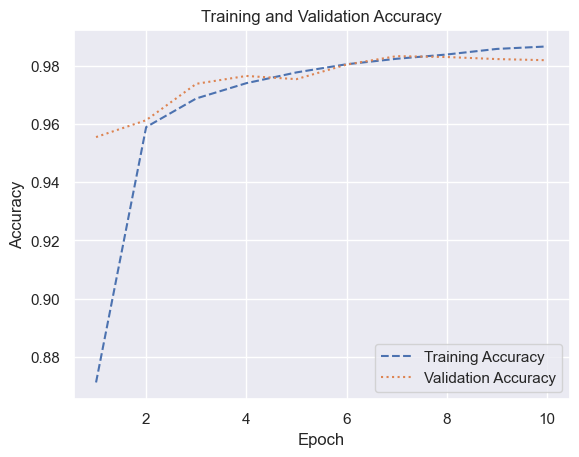

In [7]:
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "--", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");